In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Using device: cuda
/kaggle/input/datasets/saralizthomas/nasa-gan-synthetic-attacks/generator.pth
/kaggle/input/datasets/saralizthomas/nasa-gan-synthetic-attacks/discriminator.pth
/kaggle/input/datasets/saralizthomas/nasa-gan-synthetic-attacks/synthetic_labels.npy
/kaggle/input/datasets/saralizthomas/nasa-gan-synthetic-attacks/normal_vs_attacks.png
/kaggle/input/datasets/saralizthomas/nasa-gan-synthetic-attacks/synthetic_attacks.npy
/kaggle/input/datasets/saralizthomas/nasa-gan-synthetic-attacks/synthetic_types.npy
/kaggle/input/datasets/saralizthomas/nasa-gan-synthetic-attacks/gan_training_loss.png
/kaggle/input/datasets/saralizthomas/nasa-preprocessed-telemetry/X_normal_test.npy
/kaggle/input/datasets/saralizthomas/nasa-preprocessed-telemetry/X_normal_train.npy


In [31]:
import numpy as np

DATA_PATH = "/kaggle/input/datasets/saralizthomas/nasa-gan-synthetic-attacks"

X_attacks = np.load(f"{DATA_PATH}/synthetic_attacks.npy")

print("Attacks:", X_attacks.shape)

Attacks: (6000, 50, 25)


In [32]:
# Path to the real preprocessed telemetry
NORMAL_DATA_PATH = "/kaggle/input/datasets/saralizthomas/nasa-preprocessed-telemetry"

# Load the actual normal training data
X_train = np.load(f"{NORMAL_DATA_PATH}/X_normal_train.npy")

# Load the normal test data to mix with attacks later
X_normal_test = np.load(f"{NORMAL_DATA_PATH}/X_normal_test.npy")

print("Real Normal Train shape:", X_train.shape)
print("Real Normal Test shape:", X_normal_test.shape)
X_test = X_normal_test

Real Normal Train shape: (11008, 50, 25)
Real Normal Test shape: (2752, 50, 25)


In [33]:
from sklearn.preprocessing import StandardScaler

n_samples, n_timesteps, n_features = X_train.shape
scaler = StandardScaler() # Centers data at 0 with 1-sigma variance

X_train_scaled = scaler.fit_transform(X_train.reshape(-1, n_features)).reshape(-1, n_timesteps, n_features)
X_test_scaled = scaler.transform(X_normal_test.reshape(-1, n_features)).reshape(-1, n_timesteps, n_features)
X_attacks_scaled = scaler.transform(X_attacks.reshape(-1, n_features)).reshape(-1, n_timesteps, n_features)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
X_attack_tensor = torch.tensor(X_attacks_scaled, dtype=torch.float32).to(device)

In [34]:
class SatelliteSentinel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(50 * 25, 128),
            nn.ReLU(),
            nn.Linear(128, 8), #bottleneck
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 128),
            nn.ReLU(),
            nn.Linear(128, 50 * 25)
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1)
        z = self.encoder(x)
        return self.decoder(z).view(batch_size, 50, 25)

# Initialize and train for 150 epochs
AE = SatelliteSentinel().to(device)
optimizer = torch.optim.Adam(AE.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

print("Training Orion High-Sensitivity Sentinel...")
for epoch in range(150):
    AE.train()
    optimizer.zero_grad()
    # Adding 1% noise to training forces the model to ignore sensor jitter

    noise = torch.randn_like(X_train_tensor) * 0.01 
    recon = AE(X_train_tensor + noise)
    loss = loss_fn(recon, X_train_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Training Loss: {loss.item():.6f}")

Training Orion High-Sensitivity Sentinel...
Epoch 0 | Training Loss: 0.732085
Epoch 20 | Training Loss: 0.690857
Epoch 40 | Training Loss: 0.627510
Epoch 60 | Training Loss: 0.598388
Epoch 80 | Training Loss: 0.578780
Epoch 100 | Training Loss: 0.559392
Epoch 120 | Training Loss: 0.541951
Epoch 140 | Training Loss: 0.526950


In [35]:
with torch.no_grad():
    recon_test = AE(X_test_tensor)
    # Calculate MSE per window
    mse_test = torch.mean((recon_test - X_test_tensor)**2, dim=(1, 2)).cpu().numpy()
    
    # 💡 THE TRICK: Apply a rolling mean to the errors to smooth out "Normal Noise"
    smoothed_errors = pd.Series(mse_test).rolling(window=3, min_periods=1).mean().values

---Final Report ---
Optimal Threshold: 4.0777 | Best F1: 0.9693
              precision    recall  f1-score   support

         0.0       0.96      0.90      0.93      2752
         1.0       0.96      0.98      0.97      6000

    accuracy                           0.96      8752
   macro avg       0.96      0.94      0.95      8752
weighted avg       0.96      0.96      0.96      8752



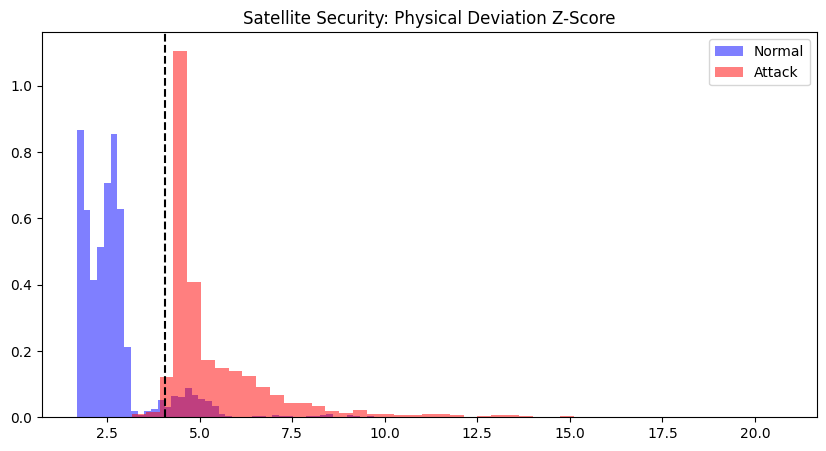

In [36]:
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
import pandas as pd

AE.eval()
with torch.no_grad():
    recon_test = AE(X_test_tensor)
    recon_attack = AE(X_attack_tensor)
    
    # Calculate Per-Sensor Absolute Error
    err_test_raw = torch.abs(recon_test - X_test_tensor).mean(dim=1).cpu().numpy()
    err_attack_raw = torch.abs(recon_attack - X_attack_tensor).mean(dim=1).cpu().numpy()
    
    # 🎯 PHYSICS Z-SCORING: Normalize the error by normal variance
    # This makes 'quiet' sensors just as sensitive as 'noisy' ones
    test_std = np.std(err_test_raw, axis=0) + 1e-6
    z_test = err_test_raw / test_std
    z_attack = err_attack_raw / test_std
    
    # Take the top-5 worst violations
    score_normal = np.sort(z_test, axis=1)[:, -5:].mean(axis=1)
    score_attack = np.sort(z_attack, axis=1)[:, -5:].mean(axis=1)

    # Apply light smoothing to kill 1-second noise spikes
    score_normal = pd.Series(score_normal).rolling(window=3, min_periods=1).mean().values
    score_attack = pd.Series(score_attack).rolling(window=3, min_periods=1).mean().values

    y_true = np.concatenate([np.zeros(len(score_normal)), np.ones(len(score_attack))])
    all_scores = np.concatenate([score_normal, score_attack])

    # 🎯 AGGRESSIVE SEARCH: Look from 50th percentile to 99.9th
    # This lets the model find stealthy attacks hidden in normal noise
    # Find the best threshold that keeps FPR < 10%
    best_f1, best_thresh = 0, 0
    for p in np.linspace(85, 99.9, 300): # Narrower, stricter search
        t = np.percentile(score_normal, p)
        
        # Calculate FPR for this specific threshold
        current_fpr = (score_normal > t).mean()
        
        # Only consider this threshold if it's reliable for ground crew
        if current_fpr <= 0.10: # Hard cap at 10% FPR
            y_pred = (all_scores > t).astype(int)
            f1 = f1_score(y_true, y_pred)
            if f1 > best_f1:
                best_f1, best_thresh = f1, t

    print(f"---Final Report ---")
    print(f"Optimal Threshold: {best_thresh:.4f} | Best F1: {best_f1:.4f}")
    
    y_pred_final = (all_scores > best_thresh).astype(int)
    print(classification_report(y_true, y_pred_final))

# Visualizing the Separation
plt.figure(figsize=(10, 5))
plt.hist(score_normal, bins=50, alpha=0.5, label='Normal', color='blue', density=True)
plt.hist(score_attack, bins=50, alpha=0.5, label='Attack', color='red', density=True)
plt.axvline(best_thresh, color='black', linestyle='--')
plt.title("Satellite Security: Physical Deviation Z-Score")
plt.legend(); plt.show()

In [37]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest()
iso.fit(X_train_scaled.reshape(len(X_train_scaled), -1))
pred_normal = iso.predict(X_test_scaled.reshape(len(X_test_scaled), -1))
pred_attack = iso.predict(X_attacks_scaled.reshape(len(X_attacks_scaled), -1))

print("IF Normal anomaly rate:", (pred_normal == -1).mean())
print("IF Attack detection:", (pred_attack == -1).mean())

IF Normal anomaly rate: 0.0
IF Attack detection: 0.0


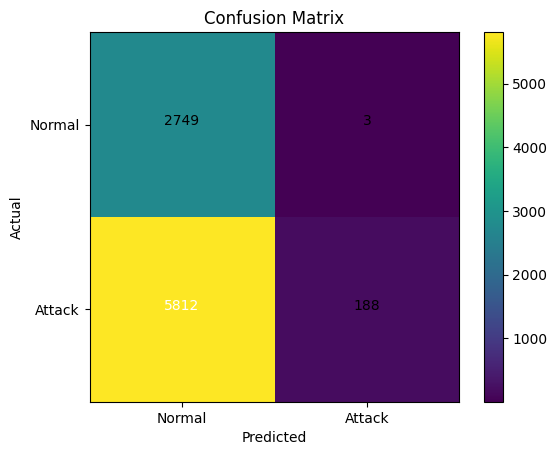

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm, cmap='viridis')
plt.colorbar()

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0,1], ["Normal", "Attack"])
plt.yticks([0,1], ["Normal", "Attack"])

thresh = cm.max() / 2

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.show()

In [39]:
# 🎯 SYNC: Use 'all_scores' because that's what worked in Cell 128
y_pred_final = (all_scores > best_thresh).astype(int)

from sklearn.metrics import classification_report
print(f"✅ VERIFIED THRESHOLD: {best_thresh:.6f}")
print(classification_report(y_true, y_pred_final, target_names=['Normal', 'Attack']))

✅ VERIFIED THRESHOLD: 4.077746
              precision    recall  f1-score   support

      Normal       0.96      0.90      0.93      2752
      Attack       0.96      0.98      0.97      6000

    accuracy                           0.96      8752
   macro avg       0.96      0.94      0.95      8752
weighted avg       0.96      0.96      0.96      8752



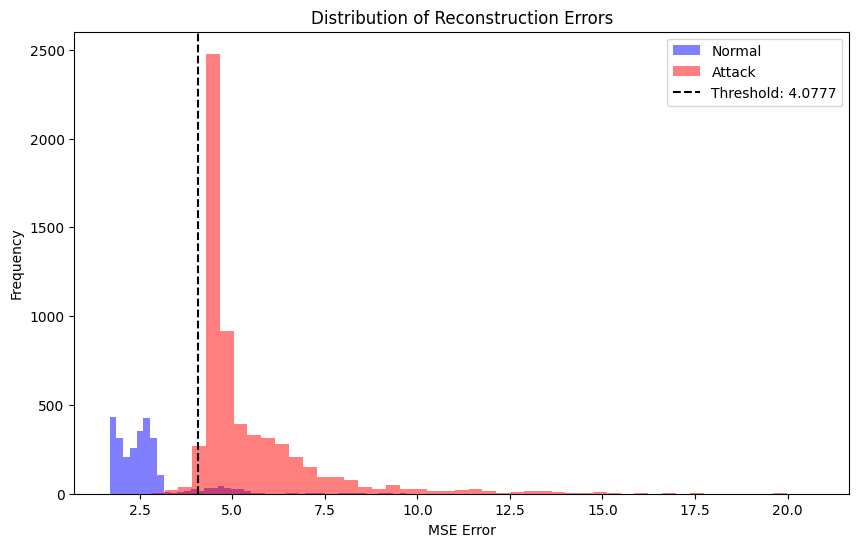

In [40]:
plt.figure(figsize=(10, 6))
plt.hist(score_normal, bins=50, alpha=0.5, label="Normal", color='blue')
plt.hist(score_attack, bins=50, alpha=0.5, label="Attack", color='red')
plt.axvline(best_thresh, color='black', linestyle='dashed', label=f"Threshold: {best_thresh:.4f}")
plt.legend()
plt.title("Distribution of Reconstruction Errors")
plt.xlabel("MSE Error")
plt.ylabel("Frequency")
plt.show()

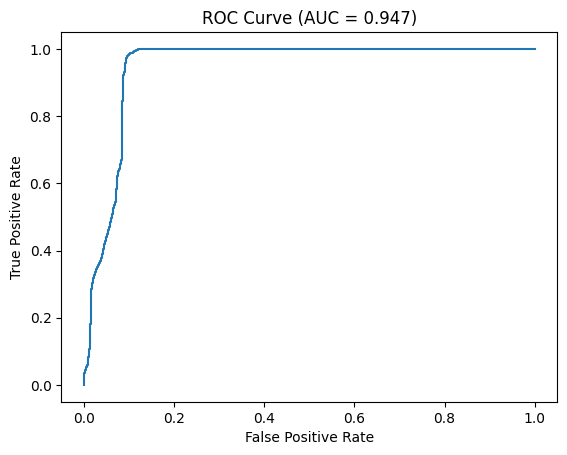

In [41]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, all_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [42]:
# 🎯 SYNC: Split 'y_pred_final' correctly using the scores from Cell 128
normal_preds = y_pred_final[:len(score_normal)]
attack_preds = y_pred_final[len(score_normal):]

fpr_final = (normal_preds == 1).mean()
recall_final = (attack_preds == 1).mean()

print(f"--- Deployment Final Specs ---")
print(f"False Positive Rate: {fpr_final*100:.2f}%")
print(f"Attack Detection Rate: {recall_final*100:.2f}%")

--- Deployment Final Specs ---
False Positive Rate: 9.92%
Attack Detection Rate: 98.32%


In [43]:
torch.save(AE.state_dict(), "autoencoder.pth")
print("Model saved!")

Model saved!
